In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows

import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats
import hera_pspec as hp
import astropy
from astropy.time import Time
from astropy.coordinates import get_sun
import astropy.units as u

In [2]:
t = Time("2024-12-05 2:27:24.3", scale="utc")

# Get Sun position (GCRS frame by default)
sun = get_sun(t)

# Convert to ICRS for RA/Dec
sun_icrs = sun.icrs

print(f"RA  = {sun_icrs.ra.to(u.hourangle):.2f}")
print(f"Dec = {sun_icrs.dec.to(u.deg):.2f}")

RA  = 14.48 hourangle
Dec = -13.22 deg


In [3]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [4]:
uvh5name[4*275]

'/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.49903.sum.uvh5'

In [5]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  
pol=uvd1.polarization_array[0]
uvd1.read(Model_complete_file, polarizations=pol) 
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [6]:

filter_name="Main_lobe_20_mHz"
filter_name_2="Notch_filter_40_mHz"
filter_name_3="Notch_filter_80_mHz"
filter_name_4="Main_lobe_baseline_dependent"
filter_name_5="Notch_filter_20_mHz"
lst="0h"
spw="low"

In [7]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
freqs = uvd1.freq_array*1e-6
dt=((lsts[1]-lsts[0])*60*60)/4
# t_total=(800*dt)/2
# t_total/3600

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [8]:
dt

np.float64(19.38026895248957)

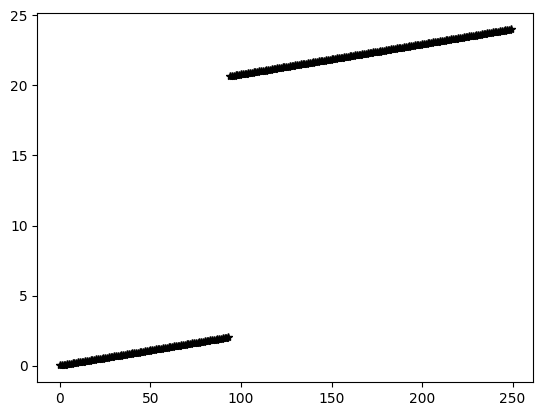

In [9]:
plt.plot(lsts, 'k*')

In [10]:

def JytomK(Jy, f0=163e6):
    """Convert Jansky to mK

    Args:
        Jy (float): brightness in Jy
        f0 (float): frequency in Hz

    Returns:
        float: brightness temperature in mK
    """

    # wavelength in m
    c=3.0e8
    lam = c / f0

    # flux density in W/m^2/Hz
    S = Jy * 1e-26
    kb=1.38064852e-23
    # temperature in K
    T = S * lam ** 2 / (2 * kb)

    # rettourn temperature in mK
    return T * 1e3

def power_spectrum(V, baseline, f1, df, delays):
    window = windows.blackmanharris(delays.shape[0])
    comso=hp.conversions.Cosmo_Conversions(Om_l=0.7,H0=70,Om_c=0.3)
    c=3e8
   
    f0=1420.0e6
    lambda_0=c/f0
    lambda_1=c/f1

    z=(lambda_1-lambda_0)/lambda_0
    factor=comso.bl_to_kperp(z=z)
    theta=(lambda_1/baseline)
    Dc=comso.dRperp_dtheta(z)*theta
    Beff=np.sum(window*df)
    Delta_D=comso.dRpara_df(z)*Beff
    k_par=comso.tau_to_kpara(z=z)*delays*1e-9
    k_per=factor*baseline
    theta_d=np.rad2deg(theta)
    Ae=theta_d**2
    

    steradian=(180.0/np.pi)**2 #degrees per steradian
    Omega= Ae/steradian
    V_mk=JytomK(Jy=V,f0=f1)
    constant=((Dc**2*Delta_D)/(Beff))*(1/(Omega*Beff))
    P=V_mk**2*constant*df**2
    
    print(" at redshift "+str(z))
    return k_par,np.array(P)
def vis_perform_delay_trans(freqs=freqs, data=""):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    
    print(len(data))
    data_full_bls=[]
    for t in range(len(data)):
        # print(t)
       
        for bls in range (len(data[t])):
            data_time_no_nans=data[t][bls][~np.isnan(data[t][bls])]
            freq_no_nans=freqs[~np.isnan(data[t][bls])]
            coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
            poly = np.poly1d(coeffs)
            x_fit=freqs
            y_fit=poly(x_fit)
            data_fitted=[]
            for i in range (data[t][bls].shape[0]):
                if np.isnan(data[t][bls][i]):
                    data_fitted.append(poly(x_fit[i]))
                else:
                    data_fitted.append(data[t][bls][i])
            data_fitted=np.array(data_fitted) 
           
            data_full_bls.append(data_fitted)
            
    data_full_bls=np.array(data_full_bls)
    print(data_full_bls.shape)
    # data_full_fitted=np.array(data_full_fitted)
    cross_power=[]
    for i in range (data_full_bls.shape[0]-1):
        # for k in range (130):
        #     if k>i:
               
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i+1]))
                cross_power.append(g0_delay*np.conjugate(g1_delay))
                # cross_power.append(np.abs(g0_delay))
                
    cross_power=np.array(cross_power)
    kpar, power_spectrum_cross_power=power_spectrum(V=cross_power, baseline=14.5, f1=62.5e6, df=122e3, delays=tau)
    return data_full_bls, power_spectrum_cross_power, kpar

In [11]:
hd = io.HERAData(uvh5name[0])
# antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
# antpos_d = dict(zip(ants, antpos))
reds = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')

In [12]:
N=100

def filter_data(cal_data):
    flag_low=67.85
    flag_high=71.20
    index_flag=np.where((freqs>=flag_low ) & (freqs<=flag_high) )
    index_flag2=np.where((freqs>=55 ) & (freqs<=63) )

    
    cal_data_filtered=[]
    for bl in cal_data:
        blvec = (antpos[np.where(ants==bl[0])] - antpos[np.where(ants==bl[1])])
        
        if np.abs(np.linalg.norm(blvec[0:2])-29)<2:

            
            cal_data_flagged=np.array(cal_data[bl][0,:])
            cal_data_flagged[index_flag]=np.nan*(np.ones(cal_data_flagged[index_flag].shape))
            # cal_data_flagged[index_flag2]=np.nan*(np.ones(cal_data_flagged[index_flag2].shape))
            cal_data_filtered.append(cal_data_flagged)
    
    return cal_data_filtered
    
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

    k=0  
    cal_all_data=[]
    for x in range(N):
        n=k+x 
        
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
  
            i=4*n
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
            cal_all_data.append(filter_data(cal_data))  
                
    for x in range(N):
        n=k+x 
        
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            i=4*n+1
    
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()
    
            cal_all_data.append(filter_data(cal_data))


    for x in range(N):
        n=k+x 
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            # print(n)
            i=4*n+2
        
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
        
            cal_all_data.append(filter_data(cal_data))    

    for x in range(N):
        n=k+x
        if n!=4 and n!=5 and n!=6 and n!=19 and n!=18: 
            i=4*n+3
   
        
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_3h_"+spw+".npy", allow_pickle=True).item()
        
            cal_all_data.append(filter_data(cal_data))                  

  
    return cal_all_data        

In [13]:
lsts[50], lsts[50+43]

(np.float64(1.091034236048284), np.float64(2.0169803298040803))

In [14]:
cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)
# #cal_data_full_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
# #cal_data_full_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

#cal_data_gleam_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

cal_data_gleam_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter_notch_80_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_3+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter_main_lobe_baseline_dependent=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_4+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_gleam_filter_notch_20_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_5+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

In [15]:
#70 to 95
n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam)
# # c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter)
# c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter)
c4, p4, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full)

c5, p5, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch)
# c6, p6, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter_notch)

# c7, p7, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_80_mHz)

# c8, p8, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_main_lobe_baseline_dependent)

c9, p9, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_20_mHz)

377
(26382, 205)
 at redshift 21.72
377
(26382, 205)
 at redshift 21.72
377
(26352, 205)
 at redshift 21.72
377
(26379, 205)
 at redshift 21.72


In [16]:

def take_mean_and_fold(tau, p):
    p_ave_in= np.mean(p, axis=0)
    p_ave=p_ave_in/np.max(np.abs(p_ave_in))
    # p_fold=np.zeros(p_ave.shape[0]/2)
    
    p_fold=[]
    
    for n in range (102):
        
        i=102-n
        p1=np.abs(p_ave[tau==tau[i]])
        p2=np.abs(p_ave[tau==-tau[i]])
        p_fold.append((p1+p2)/2)
            
    
    p_fold=np.array(p_fold)
    p_fold_complete=np.zeros(shape=(p_fold.shape[0]+1), dtype=complex)
    p_fold_complete[1:]=p_fold[:,0]
    p_fold_complete[0]=1
    return p_fold
    
    
# p_ave= take_mean_and_fold(tau, p)
# # p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
# p_ave5= take_mean_and_fold(tau, p5)
# # p_ave6= take_mean_and_fold(tau, p6)
# # p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
# p_ave9= take_mean_and_fold(tau, p9)
# # plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# # plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# # plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# # plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
# plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# # plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
# plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
# plt.xlim([0,0.4])
# plt.legend()
# # plt.savefig("paper_figures/power_spectra_two_filters_notch.pdf")

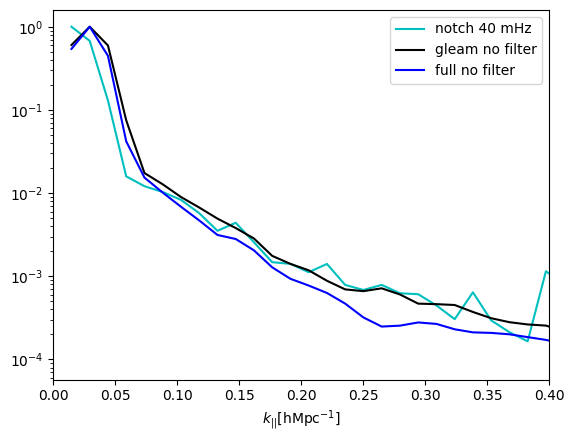

In [17]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
# p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
# p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.4])
plt.legend()
# plt.savefig("paper_figures/power_spectra_notch.pdf")

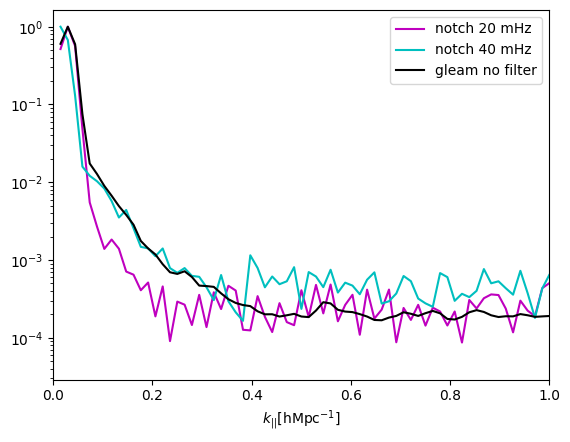

In [19]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
# p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,1])
plt.legend()
plt.savefig("paper_figures/power_spectra_two_filters_notch_29_m_all_LST.pdf")

## Chis-sqaure

In [13]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i][43:69]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [15]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_"+filter_name_5+"_redcal_"+uvh5name[i][43:69]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

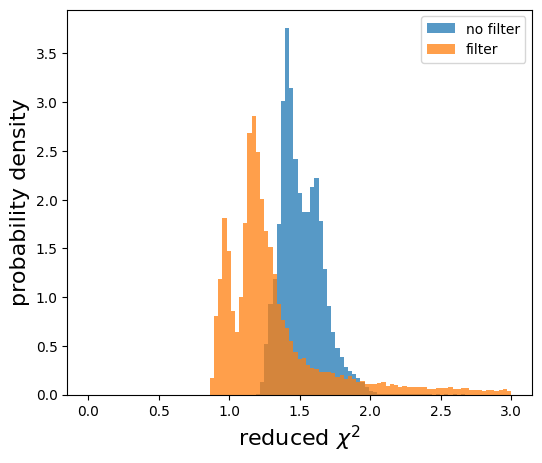

In [28]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 3), density=True, alpha=0.75,label="no filter")
plt.hist(np.abs(chis_filer.ravel())/0.15, bins=101, range=(0, 3), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [ ]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [ ]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [ ]:
pol=hd.polarization_array

In [ ]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [ ]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



In [ ]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




In [ ]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [ ]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


In [ ]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
hc.abscal.post_redcal_abscal??